In [3]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from src.urn import PolyaUrn

import numpy as np
import matplotlib.pyplot as plt

# Sensibilité des probabilités de domination aux paramètres

Dans le notebook précédent, nous avons reproduit expérimentalement le théorème de domination permanente étudié par Janson dans le cadre des urnes de Pólya généralisées.

Nous poursuivons ici l’analyse en étudiant l’influence des paramètres du modèle sur la probabilité empirique de domination permanente.

Le théorème affirme que :

$$
\mathbb P(A) > 0
$$

dans certaines conditions asymétriques, où :

$$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$$

Cependant, le résultat théorique ne précise pas :
- l’amplitude de cette probabilité ;
- sa stabilité ;
- ni son évolution selon les paramètres du système.

L’objectif de ce notebook est donc d’explorer expérimentalement comment :
- les conditions initiales ;
- les mécanismes de renforcement ;
- et leur asymétrie

modifient la fréquence empirique de l’événement \(A\).

Nous utilisons des simulations de Monte Carlo afin d’estimer ces probabilités et d’analyser les différents régimes de domination observés.

In [1]:
def estimate_probability(
    black_initial,
    white_initial,
    black_reinforcement,
    white_reinforcement,
    n_steps=1000,
    n_simulations=1000
):

    successes = 0

    for _ in range(n_simulations):

        urn = PolyaUrn(
            balls={
                "black": black_initial,
                "white": white_initial
            },
            reinforcements={
                "black": black_reinforcement,
                "white": white_reinforcement
            }
        )

        urn.simulate(n_steps)

        if urn.always_black_leading():
            successes += 1

    return successes / n_simulations

## Fonction d'estimation

Nous définissons une fonction auxiliaire qui calcule la probabilité empirique de domination permanente pour une configuration donnée des paramètres.

Cette fonction génère `n_simulations` trajectoires indépendantes et compte la proportion où l'événement $A$ est vérifié sur un horizon de `n_steps` étapes.


In [5]:
estimate_probability(
    black_initial=10,
    white_initial=5,
    black_reinforcement=2,
    white_reinforcement=1
)

0.981

## Étude 1 : influence de la condition initiale noire

Nous explorons comment la composition initiale de l'urne affecte la domination permanente.

**Setup** : nous fixons les renforcements à $(m_b, m_w) = (2,1)$ et le nombre initial de boules blanches à $W_0 = 5$, puis nous faisons varier le nombre initial de boules noires $B_0 \in \{5, 10, 15, 20\}$.

L'hypothèse est qu'un avantage initial plus grand pour le noir augmente la probabilité de domination permanente.


In [4]:
black_initial_values = [5, 10, 15, 20]

probabilities = []

In [5]:
for b0 in black_initial_values:

    p = estimate_probability(
        black_initial=b0,
        white_initial=5,
        black_reinforcement=2,
        white_reinforcement=1
    )

    probabilities.append(p)

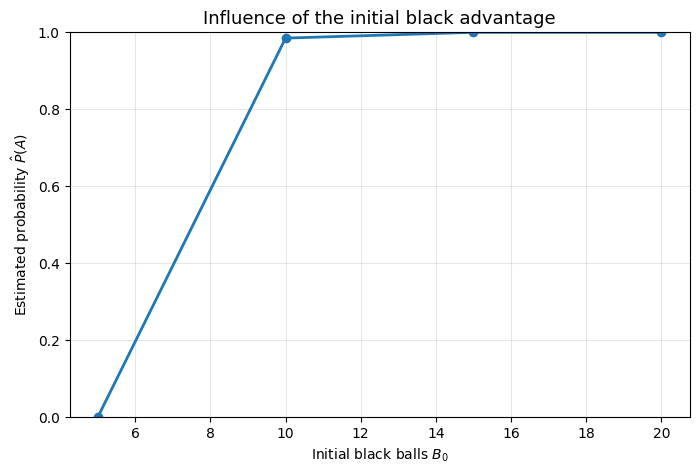

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    black_initial_values,
    probabilities,
    marker="o",
    linewidth=2
)

plt.xlabel(r"Initial black balls $B_0$")
plt.ylabel(r"Estimated probability $\hat P(A)$")

plt.ylim(0, 1)

plt.grid(alpha=0.3)

plt.title(
    "Influence of the initial black advantage",
    fontsize=13
)

plt.show()

### Observation

La courbe montre une relation monotone entre l'avantage initial du noir et la probabilité empirique de domination permanente.

Cette observation empirique est conforme à l'intuition : un écart initial plus grand entre les deux couleurs réduit la probabilité que le blanc rattrape ou dépasse le noir, même en présence de fluctuations aléatoires précoces.

Cependant, même avec $B_0 = 5$ (égalité moins la minorité blanche), la probabilité reste non négligeable. Cela illustre le rôle du renforcement asymétrique $(2, 1)$ qui favorise fortement le noir une fois que des tirages noirs sont observés.


## Étude 2 : influence de l'asymétrie du renforcement

Nous explorons maintenant l'effet de l'asymétrie entre les deux mécanismes de renforcement.

**Setup** : nous fixons les conditions initiales à $(B_0, W_0) = (10, 5)$ et les renforcements du noir à $m_b = 2$, puis nous faisons varier le renforcement du blanc $m_w \in \{0.5, 1, 2, 3\}$.

À mesure que $m_w$ augmente, le mécanisme de renforcement devient plus symétrique, ce qui devrait réduire l'avantage structurel du noir.


In [7]:
white_reinforcement_values = [0.5, 1, 2, 3]

probabilities_reinforcement = []

for mw in white_reinforcement_values:

    p = estimate_probability(
        black_initial=10,
        white_initial=5,
        black_reinforcement=2,
        white_reinforcement=mw
    )

    probabilities_reinforcement.append(p)


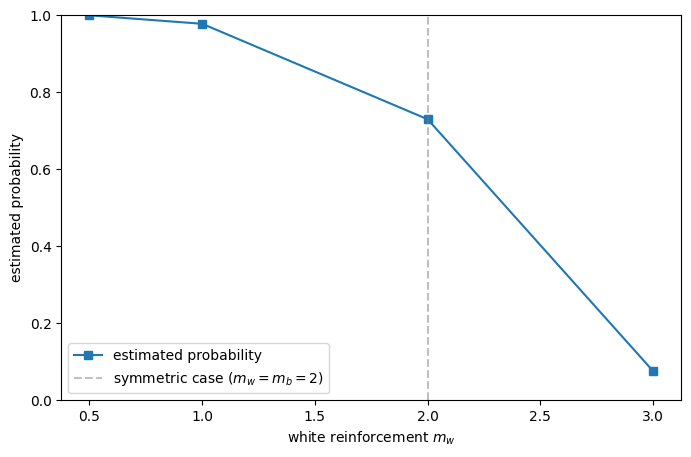

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    white_reinforcement_values,
    probabilities_reinforcement,
    marker="s",
    label="estimated probability"
)

plt.axvline(x=2, color="gray", linestyle="--", alpha=0.5, label="symmetric case ($m_w = m_b = 2$)")

plt.xlabel("white reinforcement $m_w$")
plt.ylabel("estimated probability")

plt.ylim(0, 1)

plt.legend()

plt.show()


### Observation

La courbe montre une décroissance monotone de la probabilité de domination permanente à mesure que le renforcement du blanc augmente.

Cette tendance illustre l'importance du mécanisme de renforcement asymétrique :
- Quand $m_w = 0.5$, le blanc est gravement désavantagé, et la domination du noir est quasi certaine même sur 100 étapes.
- À mesure que $m_w$ se rapproche de $m_b = 2$, le mécanisme devient plus équilibré, ce qui réduit l'avantage structurel du noir.
- Quand $m_w \geq m_b$, le blanc bénéficie d'un renforcement au moins égal à celui du noir, et la probabilité de domination permanente du noir diminue fortement.

Cet effet empirique souligne le rôle critique du renforcement asymétrique dans la stabilisation de la domination d'une couleur.


## Synthèse

Les deux expériences menées dans ce notebook révèlent des tendances claires sur la sensibilité de la probabilité empirique de domination permanente aux paramètres du modèle :

1. **Effet des conditions initiales** : un avantage initial du noir augmente de façon monotone la probabilité de domination permanente. Cet effet est intuitif mais néanmoins important pour quantifier.

2. **Effet du renforcement** : l'asymétrie du mécanisme de renforcement est déterminante. Un renforcement favorable au noir stabilise sa domination, tandis qu'un renforcement symétrique ou plus favorable au blanc réduit drastiquement la probabilité de domination permanente.

Ces résultats empiriques suggèrent que la domination permanente est une propriété fragile qui dépend sensiblement de la combinaison :
- de l'avantage initial,
- du mécanisme de renforcement asymétrique.

Une étude théorique détaillée serait nécessaire pour caractériser précisément cette dépendance en fonction de l'horizon temporel et du régime asymptotique.


## Conclusion

Les expériences réalisées dans ce notebook montrent que les hypothèses du théorème de Janson influencent fortement la stabilité empirique de la domination permanente.

Les simulations indiquent notamment que :
- un avantage initial plus important augmente la stabilité de la domination noire ;
- une asymétrie de renforcement favorable renforce fortement la probabilité empirique de domination permanente ;
- les régimes proches de la symétrie restent beaucoup plus sensibles aux fluctuations aléatoires.

Ces résultats prolongent l’étude théorique en fournissant une interprétation expérimentale du rôle joué par les paramètres du modèle dans l’apparition de l’événement :

$$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$$

Le notebook suivant s’intéressera maintenant à la dynamique temporelle de cette domination, notamment au temps nécessaire pour atteindre un régime stable.